# Homework 6
You need to classify digits with SVM models in this homework. Use PCA to reduce data dimensionality (80% information remain). Compare performance of linear, radial, and polynomial kernals. Tune kernal parameters using Randomsearch method.

Original data shape: (1797, 64)
Transformed data shape (after PCA): (1797, 21)
Linear SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.94      0.98      0.96        50
           2       0.96      0.98      0.97        47
           3       0.94      0.93      0.93        54
           4       0.98      1.00      0.99        60
           5       0.95      0.94      0.95        66
           6       0.98      0.98      0.98        53
           7       0.98      0.98      0.98        55
           8       0.93      0.93      0.93        43
           9       0.93      0.90      0.91        59

    accuracy                           0.96       540
   macro avg       0.96      0.96      0.96       540
weighted avg       0.96      0.96      0.96       540

RBF SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.0

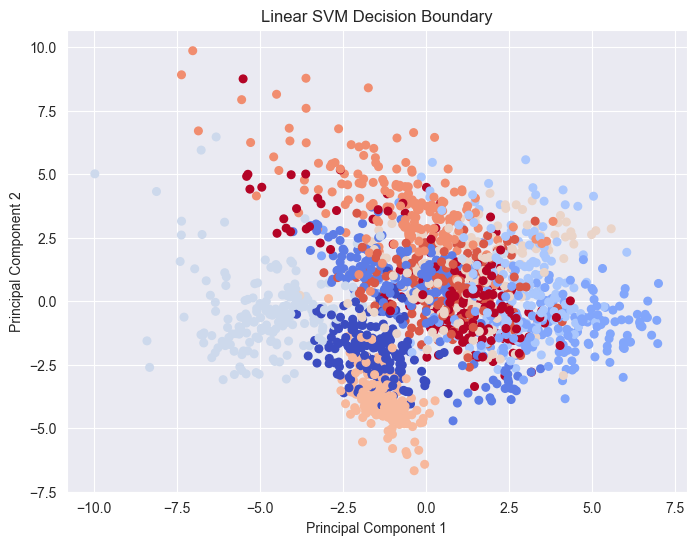

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, svm, metrics
from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Load digits dataset
digits = datasets.load_digits()
X = digits.data
y = digits.target

# Standardizing the data (important before PCA and SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=0.80)  # Retain 80% of the variance
X_pca = pca.fit_transform(X_scaled)

# Check the shape after PCA
print(f"Original data shape: {X.shape}")
print(f"Transformed data shape (after PCA): {X_pca.shape}")

# Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# SVM Classification with Different Kernels
# Linear SVM
svm_linear = svm.SVC(kernel='linear')
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
print("Linear SVM Classification Report:")
print(metrics.classification_report(y_test, y_pred_linear))

# Radial Basis Function (RBF) SVM
svm_rbf = svm.SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
print("RBF SVM Classification Report:")
print(metrics.classification_report(y_test, y_pred_rbf))

# Polynomial SVM
svm_poly = svm.SVC(kernel='poly')
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)
print("Polynomial SVM Classification Report:")
print(metrics.classification_report(y_test, y_pred_poly))

# Parameter Tuning using RandomizedSearchCV
# Hyperparameter search for RBF kernel
param_dist_rbf = {'C': [0.1, 1, 10, 100],
                  'gamma': ['scale', 'auto', 0.1, 1, 10]}

random_search_rbf = RandomizedSearchCV(svm.SVC(kernel='rbf'), param_dist_rbf, n_iter=10, cv=5, random_state=42)
random_search_rbf.fit(X_train, y_train)
print("Best parameters for RBF kernel:", random_search_rbf.best_params_)

# Hyperparameter search for Polynomial kernel
param_dist_poly = {'C': [0.1, 1, 10, 100],
                   'degree': [2, 3, 4]}

random_search_poly = RandomizedSearchCV(svm.SVC(kernel='poly'), param_dist_poly, n_iter=10, cv=5, random_state=42)
random_search_poly.fit(X_train, y_train)
print("Best parameters for Polynomial kernel:", random_search_poly.best_params_)

# 5-Fold Cross-Validation to Get Final Accuracy
# Cross-validation for the best models
cv_results_linear = cross_val_score(svm.SVC(kernel='linear', C=1), X_pca, y, cv=5)
cv_results_rbf = cross_val_score(
    svm.SVC(kernel='rbf', C=random_search_rbf.best_params_['C'], gamma=random_search_rbf.best_params_['gamma']), X_pca,
    y, cv=5)
cv_results_poly = cross_val_score(
    svm.SVC(kernel='poly', C=random_search_poly.best_params_['C'], degree=random_search_poly.best_params_['degree']),
    X_pca, y, cv=5)

print(f"Linear SVM 5-fold CV score: {cv_results_linear.mean()}")
print(f"RBF SVM 5-fold CV score: {cv_results_rbf.mean()}")
print(f"Polynomial SVM 5-fold CV score: {cv_results_poly.mean()}")


# Visualization (Optional)
def plot_svm_decision_boundaries(X, y, model, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=30)
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()


# Example plot for the linear SVM
plot_svm_decision_boundaries(X_pca, y, svm_linear, "Linear SVM Decision Boundary")
